In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\data\Raw\train.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
df.isnull().sum()
df['Date'] = pd.to_datetime(df['Date'])
df.drop_duplicates(inplace=True)

In [4]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day'] = df['Date'].dt.day_name()

<Axes: xlabel='Date'>

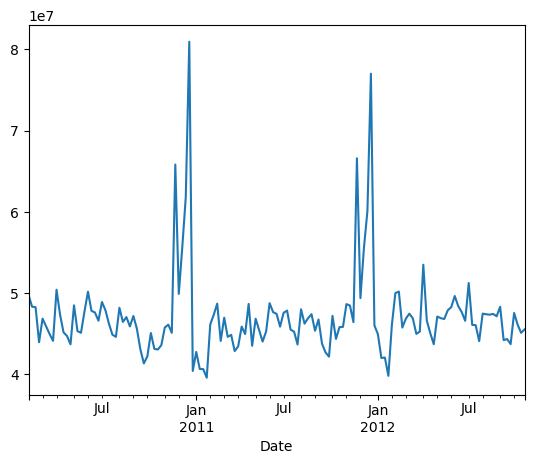

In [5]:
monthly_sales = df.groupby('Date')['Weekly_Sales'].sum()
monthly_sales.plot()

In [6]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

In [7]:
df.groupby('IsHoliday')['Weekly_Sales'].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [8]:
df = df.sort_values('Date')
df = df.reset_index(drop=True)

In [9]:
df['forecast'] = df['Weekly_Sales'].rolling(window=8,min_periods=4).mean()

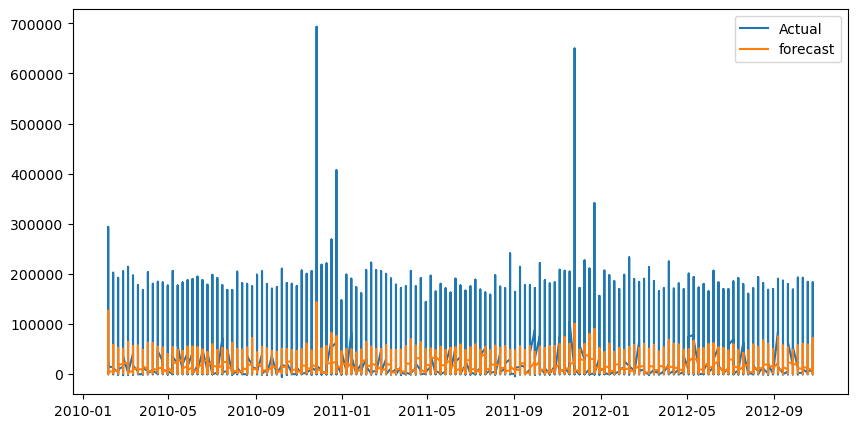

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Weekly_Sales'], label='Actual')
plt.plot(df['Date'], df['forecast'], label='forecast')
plt.legend()
plt.show()



In [11]:
total_sales = df['Weekly_Sales'].sum()
print(total_sales)

6737218987.110001


In [12]:
df.to_csv(r"C:\data\Raw\forecast_data.csv",index=False)